In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
import zipfile
from google.colab import files

# Step 1: Upload the zip file
uploaded = files.upload()

# Step 2: Extract and read CSV from ZIP
for fn in uploaded.keys():
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, 'r') as z:
            # List all files in the zip
            print("Files in zip:", z.namelist())

            # Assuming the first file is the CSV you want
            with z.open(z.namelist()[0]) as f:
                df = pd.read_excel(f, encoding='ISO-8859-1')
                print(df.head())


Saving hotel_bookings.csv.xlsx to hotel_bookings.csv.xlsx


In [ ]:
df = pd.read_excel("/content/hotel_bookings.csv.xlsx")
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


Cleaning the data

In [ ]:
df.shape

(119390, 32)

In [ ]:
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
def data_clean(df):
   df.fillna(0,inplace = True)
   print(df.isna().sum())


In [ ]:
data_clean(df)

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [ ]:
list_cols = ["children", "adults", "babies"]
for col in list_cols:
    unique_vals = df[col].unique()
    print(f"{col} has unique values as {unique_vals}")


children has unique values as [ 0.  1.  2. 10.  3.]
adults has unique values as [ 2  1  3  4 40 26 50 27 55  0 20  6  5 10]
babies has unique values as [ 0  1  2 10  9]


In [ ]:
#clean the data
filtered_data = (df['children'] == 0) & (df['adults'] == 0) & (df['babies'] == 0)
final_data = df[filtered_data]

In [ ]:
final_data.shape

(180, 32)

Where do the guest come from?(Spatial Analysis)

In [ ]:
country_wise_data = final_data[final_data['is_canceled'] == 0]['country'].value_counts().reset_index()

country_wise_data.columns = ['country','no_of_guests']
print(country_wise_data)

   country  no_of_guests
0      PRT            94
1      FRA            13
2      ESP             8
3      GBR             8
4      ITA             5
5      SWE             4
6      CHE             4
7      USA             4
8      RUS             2
9      DEU             2
10     BRA             2
11     SVN             1
12     FIN             1
13     NLD             1
14     SGP             1
15     POL             1
16     LUX             1
17     IRN             1
18     IRL             1
19     IND             1


In [ ]:
data_resort = df[df['hotel'] == 'Resort Hotel']
data_resort_adr_month = data_resort.groupby(['arrival_date_month'])['adr'].mean().reset_index()
print(data_resort_adr_month)

   arrival_date_month         adr
0               April   77.849496
1              August  186.790574
2            December   68.984230
3            February   55.171930
4             January   49.461883
5                July  155.181299
6                June  110.444749
7               March   57.520147
8                 May   78.758134
9            November   48.273993
10            October   62.097617
11          September   93.252030


In [ ]:
import plotly.express as px

map_guests = px.choropleth(
    data_frame=country_wise_data,
    locations='country',
    color='no_of_guests',
    hover_name='country',
    title='Home Country of Guests',
    color_continuous_scale='Viridis'  # Optional: Better color scale
)

map_guests.update_layout(geo=dict(showframe=False, projection_type='equirectangular'))  # Optional: map styling
map_guests.show()


How much do guests pay for a room per night?

In [ ]:
final_data["hotel"].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [ ]:
df["adr"]

,adr
0,0.00
1,0.00
2,75.00
3,75.00
4,98.00
...,...
119385,96.14
119386,225.43
119387,157.71
119388,104.40


In [ ]:
data = final_data[final_data['is_canceled'] == 0]


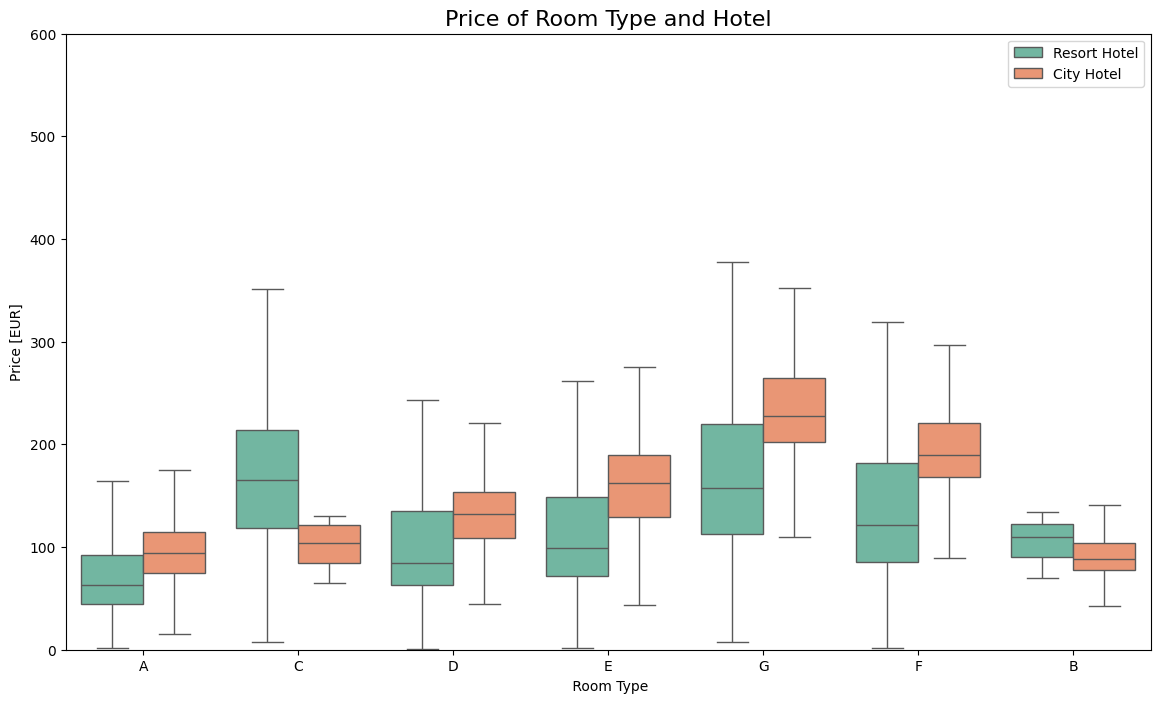

In [ ]:
#Box plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.boxplot(
    x='reserved_room_type',
    y='adr',
    hue='hotel',
    data=filtered_df,
    palette='Set2',
    showfliers=False
)

plt.title("Price of Room Type and Hotel", fontsize=16)
plt.xlabel(" Room Type")
plt.ylabel("Price [EUR]")
plt.legend(loc ="upper right")
plt.ylim(0, 600)
plt.show()


#How does the price per night (adr) vary over the year?

In [ ]:

final_data = df[df['is_cancelled'] == 0]

# Step 3: Filter by hotel type
data_resort = final_data[final_data['hotel'] == 'Resort Hotel']
data_city = final_data[final_data['hotel'] == 'City Hotel']




In [ ]:
resort_hotel = data_resort.groupby(['arrival_date_month'])['adr'].mean().reset_index()
resort_city = data_resort.groupby(['arrival_date_month'])['adr'].mean().reset_index()

In [ ]:
data_city = df[df['hotel'] == 'City Hotel']
city_hotel= data_city.groupby(['arrival_date_month'])['adr'].mean().reset_index()

In [ ]:
final = data_resort_adr_month.merge(city_hotel, on='arrival_date_month')
final.columns = ["month","price_for_resort_hotel","price_for_city_hotel"]
print(final)

        month  price_for_resort_hotel  price_for_city_hotel
0       April               77.849496            111.251838
1      August              186.790574            114.680455
2    December               68.984230             88.826307
3    February               55.171930             85.088278
4     January               49.461883             82.628986
5        July              155.181299            110.734292
6        June              110.444749            119.074341
7       March               57.520147             92.643116
8         May               78.758134            121.638560
9    November               48.273993             88.069601
10    October               62.097617             99.974498
11  September               93.252030            110.004661


In [ ]:
test = final

In [ ]:
#Sort the month
from calendar import month_name
def sort_month(df,colname):
   month_dict = { j:i for i,j in enumerate(month_name)}
   df["month_num"] = df[colname].apply(lambda x: month_dict[x])
   return df.sort_values(by = "month_num").reset_index().drop(['index','month_num'],axis = 1)


In [ ]:
sort_month(test,"month")

,month,price_for_resort_hotel,price_for_city_hotel
0,January,49.461883,82.628986
1,February,55.171930,85.088278
2,March,57.520147,92.643116
3,April,77.849496,111.251838
4,May,78.758134,121.638560
5,June,110.444749,119.074341
6,July,155.181299,110.734292
7,August,186.790574,114.680455
8,September,93.252030,110.004661
9,October,62.097617,99.974498


<Axes: xlabel='month'>

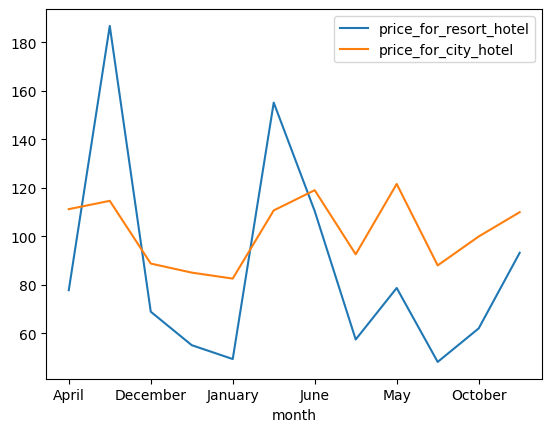

In [ ]:
final.plot(kind = "line",x = "month",y =["price_for_resort_hotel","price_for_city_hotel"])

Which are the most busy month or in which months guests are high?

In [ ]:
data_resort.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
data_resort['arrival_date_month'].value_counts().reset_index()

,arrival_date_month,count
0,August,4894
1,July,4573
2,April,3609
3,May,3559
4,October,3555
5,March,3336
6,September,3108
7,February,3103
8,June,3045
9,December,2648


In [ ]:
rush_resort = data_resort['arrival_date_month'].value_counts().reset_index()
rush_resort.columns = ['month','no_of_guests']
print(rush_resort)

        month  no_of_guests
0      August          4894
1        July          4573
2       April          3609
3         May          3559
4     October          3555
5       March          3336
6   September          3108
7    February          3103
8        June          3045
9    December          2648
10   November          2437
11    January          2193


In [ ]:
data_city = df[df['hotel'] == 'City Hotel']
rush_city = data_city['arrival_date_month'].value_counts().reset_index()
rush_city.columns = ['month','no_of_guests']
print(rush_city)

        month  no_of_guests
0      August          8983
1         May          8232
2        July          8088
3        June          7894
4     October          7605
5       April          7480
6   September          7400
7       March          6458
8    February          4965
9    November          4357
10   December          4132
11    January          3736


In [ ]:
#Merge to DataFrame
final_rush = rush_resort.merge(rush_city,on = "month")
final_rush.columns = ["month","no.of guests in resort","no.of guests in city"]
print(final_rush)

        month  no.of guests in resort  no.of guests in city
0      August                    4894                  8983
1        July                    4573                  8088
2       April                    3609                  7480
3         May                    3559                  8232
4     October                    3555                  7605
5       March                    3336                  6458
6   September                    3108                  7400
7    February                    3103                  4965
8        June                    3045                  7894
9    December                    2648                  4132
10   November                    2437                  4357
11    January                    2193                  3736


In [ ]:
#Sort the month
from calendar import month_name
def sort_month(df,colname):
   month_dict = { j:i for i,j in enumerate(month_name)}
   df["month_num"] = df[colname].apply(lambda x: month_dict[x])
   return df.sort_values(by = "month_num").reset_index().drop(['index','month_num'],axis = 1)

final_rush = sort_month(final_rush,"month")
print(final_rush)

        month  no.of guests in resort  no.of guests in city
0     January                    2193                  3736
1    February                    3103                  4965
2       March                    3336                  6458
3       April                    3609                  7480
4         May                    3559                  8232
5        June                    3045                  7894
6        July                    4573                  8088
7      August                    4894                  8983
8   September                    3108                  7400
9     October                    3555                  7605
10   November                    2437                  4357
11   December                    2648                  4132


<Axes: xlabel='month'>

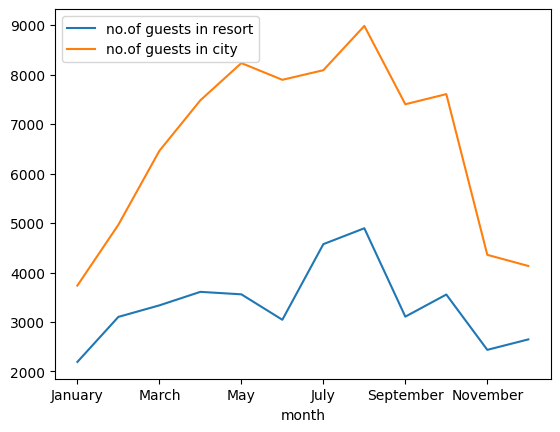

In [ ]:
#line plot
final_rush.plot(kind = "line",x = "month",
                y =["no.of guests in resort","no.of guests in city"])

How long do people stay at the hotels?

In [ ]:
final_condition = data['is_canceled'] == 0
clean_data = data[final_condition]

In [ ]:
clean_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


In [ ]:

clean_data['total_nights'] = clean_data['stays_in_weekend_nights'] + clean_data['stays_in_week_nights']

print(clean_data[['stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights']].head())


      stays_in_weekend_nights  stays_in_week_nights  total_nights
2224                        0                     3             3
2409                        0                     0             0
3181                        1                     2             3
3684                        1                     4             5
3708                        2                     4             6


In [ ]:
stay = clean_data.groupby(["total_nights","hotel"]).agg('count').reset_index()
stay.iloc[:,0:3]


,total_nights,hotel,is_canceled
0,0,City Hotel,57
1,0,Resort Hotel,1
2,1,City Hotel,14
3,1,Resort Hotel,1
4,2,City Hotel,9
5,3,City Hotel,6
6,3,Resort Hotel,2
7,4,City Hotel,10
8,5,City Hotel,11
9,5,Resort Hotel,1


In [ ]:
stay = clean_data.groupby(["total_nights","hotel"]).agg('count').reset_index()
stay = stay.rename(columns = {"is_canceled" : "no_of_stays"})

In [ ]:
print(stay)

    total_nights         hotel  no_of_stays  lead_time  arrival_date_year  \
0              0    City Hotel           57         57                 57   
1              0  Resort Hotel            1          1                  1   
2              1    City Hotel           14         14                 14   
3              1  Resort Hotel            1          1                  1   
4              2    City Hotel            9          9                  9   
5              3    City Hotel            6          6                  6   
6              3  Resort Hotel            2          2                  2   
7              4    City Hotel           10         10                 10   
8              5    City Hotel           11         11                 11   
9              5  Resort Hotel            1          1                  1   
10             6    City Hotel            5          5                  5   
11             6  Resort Hotel            1          1                  1   

<Axes: xlabel='total_nights', ylabel='no_of_stays'>

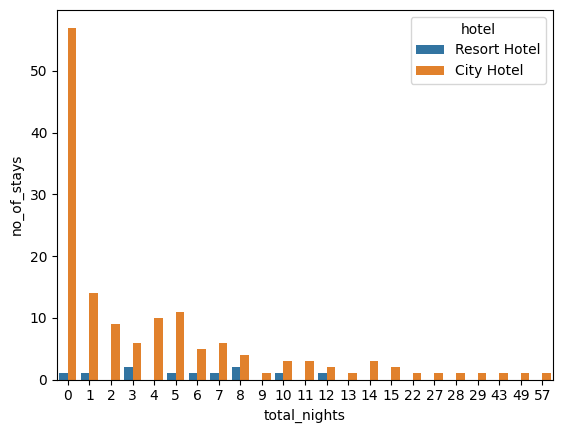

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#plot the Barplot
sns.barplot(x = "total_nights", y = "no_of_stays", hue = "hotel",
            hue_order = ["Resort Hotel","City Hotel"],data = stay)

Select important numerical features using correlation


In [ ]:
correlation = final_data.select_dtypes(include=np.number).corr()

In [ ]:
correlation = correlation["is_canceled"][1:]

In [ ]:
correlation.abs().sort_values(ascending = False)

,is_canceled
company,0.361238
lead_time,0.214011
booking_changes,0.210018
arrival_date_day_of_month,0.203425
is_repeated_guest,0.196650
total_of_special_requests,0.152038
adr,0.132921
arrival_date_year,0.108508
stays_in_week_nights,0.100054
stays_in_weekend_nights,0.083849


In [ ]:
list_remove = ["days_is_waiting_list", "arrival_date_year"]

In [ ]:
[col for col in final_data.columns if final_data[col].dtype == "O" and col not in list_remove]

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status']

In [ ]:
num_features = [col for col in final_data.columns if final_data[col].dtype != "O" and col not in list_remove]

In [ ]:
print(num_features)

['is_canceled', 'lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status_date']


Select important Categorical features


In [ ]:
import pandas as pd
import zipfile
from google.colab import files

# Step 1: Upload the zip file
uploaded = files.upload()

# Step 2: Extract and read CSV from ZIP
for fn in uploaded.keys():
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, 'r') as z:
            # List all files in the zip
            print("Files in zip:", z.namelist())

            # Assuming the first file is the CSV you want
            with z.open(z.namelist()[0]) as f:
                df = pd.read_excel(f)
                print(df.head())



Saving hotel_bookings.csv.zip to hotel_bookings.csv (2).zip
Files in zip: ['hotel_bookings.csv.xlsx']
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ... 

In [ ]:
final_data['reservation_status'].value_counts()

,count
reservation_status,
Check-Out,155
Canceled,24
No-Show,1


In [ ]:
list_remove = ["days_is_waiting_list", "arrival_date_year"]
[col for col in final_data.columns if final_data[col].dtype == "O" and col not in list_remove]

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status']

In [ ]:
cat_remove = ["country", "reservation_status","booking_changes","assigned_room_type","days_in_wating"]

In [ ]:
cat_features = [col for col in final_data.columns
                if final_data[col].dtype == "O" and col not in cat_remove]

In [ ]:
print(cat_features)

['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']


In [ ]:
list_remove = ["days_is_waiting_list", "arrival_date_year"]
num_features = [col for col in final_data.columns if final_data[col].dtype != "O" and col not in list_remove]
print(num_features)

['is_canceled', 'lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status_date']


In [ ]:
final_data[cat_features]

,hotel,arrival_date_month,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type
2224,Resort Hotel,October,SC,Corporate,Corporate,A,No Deposit,Transient-Party
2409,Resort Hotel,October,SC,Corporate,Corporate,A,No Deposit,Transient
3181,Resort Hotel,November,SC,Groups,TA/TO,A,No Deposit,Transient-Party
3684,Resort Hotel,December,SC,Groups,TA/TO,A,No Deposit,Transient-Party
3708,Resort Hotel,December,SC,Groups,TA/TO,A,No Deposit,Transient-Party
...,...,...,...,...,...,...,...,...
115029,City Hotel,June,BB,Online TA,TA/TO,A,No Deposit,Transient
115091,City Hotel,June,SC,Complementary,Direct,E,No Deposit,Transient
116251,City Hotel,July,SC,Online TA,TA/TO,A,No Deposit,Transient
116534,City Hotel,July,SC,Online TA,TA/TO,A,No Deposit,Transient-Party


In [ ]:
data_cat = final_data[cat_features]

In [ ]:
print(data_cat.head())

             hotel arrival_date_month meal market_segment  \
2224  Resort Hotel            October   SC      Corporate   
2409  Resort Hotel            October   SC      Corporate   
3181  Resort Hotel           November   SC         Groups   
3684  Resort Hotel           December   SC         Groups   
3708  Resort Hotel           December   SC         Groups   

     distribution_channel reserved_room_type deposit_type    customer_type  
2224            Corporate                  A   No Deposit  Transient-Party  
2409            Corporate                  A   No Deposit        Transient  
3181                TA/TO                  A   No Deposit  Transient-Party  
3684                TA/TO                  A   No Deposit  Transient-Party  
3708                TA/TO                  A   No Deposit  Transient-Party  


In [ ]:
final_data['reservation_status_date'] = pd.to_datetime(final_data['reservation_status_date'])

In [ ]:
print(final_data['reservation_status_date'])

2224     2015-10-06
2409     2015-10-12
3181     2015-11-23
3684     2016-01-04
3708     2016-01-05
            ...    
115029   2017-06-30
115091   2017-07-01
116251   2017-07-17
116534   2017-07-22
117087   2017-07-29
Name: reservation_status_date, Length: 180, dtype: datetime64[ns]


In [ ]:
final_data["year"] = final_data["reservation_status_date"].dt.year
final_data["month"] = final_data["reservation_status_date"].dt.month
final_data["day"] = final_data["reservation_status_date"].dt.day
final_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,year,month,day
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06,2015,10,6
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,0,Transient,0.0,0,0,Check-Out,2015-10-12,2015,10,12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23,2015,11,23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04,2016,1,4
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05,2016,1,5


In [ ]:
final_data.drop("reservation_status_date" , axis = 1, inplace = True)
final_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,year,month,day
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015,10,6
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,174.0,0,Transient,0.0,0,0,Check-Out,2015,10,12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015,11,23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016,1,4
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016,1,5


Feature Encoding


In [ ]:
#Mean Encoding Technique
final_data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'year', 'month', 'day'],
      dtype='object')

In [ ]:
final_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,year,month,day
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015,10,6
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,174.0,0,Transient,0.0,0,0,Check-Out,2015,10,12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015,11,23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016,1,4
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016,1,5


In [ ]:
final_data['cancellation'] = final_data['is_canceled']

In [ ]:
print(final_data)

           hotel  is_canceled  lead_time  arrival_date_year  \
2224    0.153846          0.0   0.200000               2015   
2409    0.153846          0.0   0.160494               2015   
3181    0.153846          0.0   0.000000               2015   
3684    0.153846          0.0   0.000000               2015   
3708    0.153846          0.0   0.000000               2015   
...          ...          ...        ...                ...   
115029  0.137725          0.0   0.000000               2017   
115091  0.137725          0.0   0.200000               2017   
116251  0.137725          0.0   0.000000               2017   
116534  0.137725          0.0   0.000000               2017   
117087  0.137725          0.0   0.000000               2017   

       arrival_date_month  arrival_date_week_number  \
2224              October                        41   
2409              October                        42   
3181             November                        47   
3684             Decemb

In [ ]:
def mean_encode(df,col,mean_col):
    df_dict = df.groupby(col)[mean_col].mean().to_dict()
    df[col] = df[col].map(df_dict)
    return df
for col in final_data.columns[0:3]:
    final_data = mean_encode(final_data,col,"cancellation")


In [ ]:
final_data['cancellation'] = final_data['is_canceled']
final_data.drop(["cancellation"],axis = 1,inplace=True)
print(final_data)

           hotel  is_canceled  lead_time  arrival_date_year  \
2224    0.153846          0.0   0.200000               2015   
2409    0.153846          0.0   0.160494               2015   
3181    0.153846          0.0   0.000000               2015   
3684    0.153846          0.0   0.000000               2015   
3708    0.153846          0.0   0.000000               2015   
...          ...          ...        ...                ...   
115029  0.137725          0.0   0.000000               2017   
115091  0.137725          0.0   0.200000               2017   
116251  0.137725          0.0   0.000000               2017   
116534  0.137725          0.0   0.000000               2017   
117087  0.137725          0.0   0.000000               2017   

       arrival_date_month  arrival_date_week_number  \
2224              October                        41   
2409              October                        42   
3181             November                        47   
3684             Decemb

In [ ]:
num_data = final_data[num_features]
final_data = final_data
dataframe = pd.concat([num_data, final_data], axis=1)
print(dataframe.head())

         hotel  is_canceled  lead_time  arrival_date_year  \
2224  0.153846          0.0   0.200000               2015   
2409  0.153846          0.0   0.160494               2015   
3181  0.153846          0.0   0.000000               2015   
3684  0.153846          0.0   0.000000               2015   
3708  0.153846          0.0   0.000000               2015   

      arrival_date_week_number  arrival_date_day_of_month  \
2224                        41                          6   
2409                        42                         12   
3181                        47                         20   
3684                        53                         30   
3708                        53                         30   

      stays_in_weekend_nights  stays_in_week_nights  adults  children  ...  \
2224                        0                     3       0       0.0  ...   
2409                        0                     0       0       0.0  ...   
3181                        1   

Handle the Outliers

In [ ]:
dataframe.describe()["adr"]

,adr,adr
count,180.000000,180.000000
mean,10.456500,10.456500
std,31.681635,31.681635
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,200.000000,200.000000


Feature importance


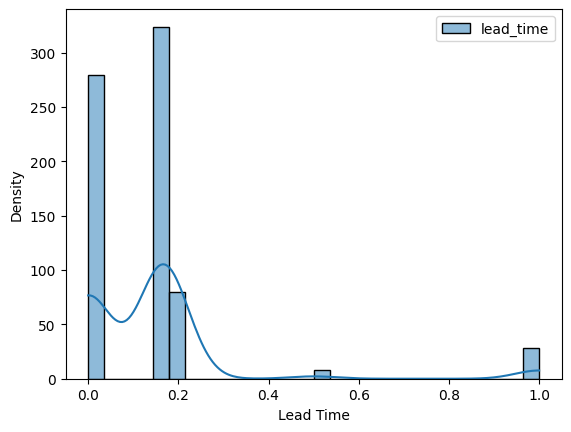

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution plot for 'lead_time' with axis labels
sns.histplot(dataframe["lead_time"], kde=True)

# Add axis labels
plt.xlabel("Lead Time")
plt.ylabel("Density")

# Show the plot
plt.show()


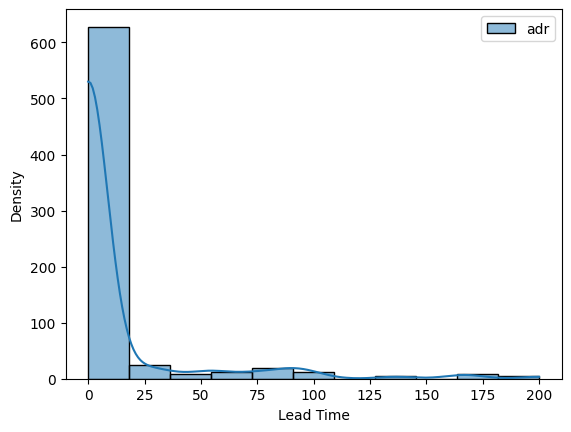

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution plot for 'lead_time' with axis labels
sns.histplot(dataframe["adr"], kde=True)

# Add axis labels
plt.xlabel("Lead Time")
plt.ylabel("Density")

# Show the plot
plt.show()


In [ ]:
y = dataframe['is_canceled']
x = dataframe.drop(['is_canceled'],axis = 1)

In [ ]:
x.columns

Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'year', 'month', 'day', 'hotel',
       'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'custom

In [ ]:
# Select categorical features from x
categorical_features = x.select_dtypes(include='object').columns

# Apply one-hot encoding
x_encoded = pd.get_dummies(x, columns=categorical_features, drop_first=True)

# Fill missing values with 0
x_encoded.fillna(0, inplace=True)

# Fit the feature selection model with the encoded data
feature_sel_model = SelectFromModel(Lasso(alpha = 0.005, random_state = 0).fit(x_encoded, y))

In [ ]:
feature_sel_model.get_support()

array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False,  True,  True,  True, False,  True,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False])

In [ ]:
cols = x.columns
print(cols)

Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'year', 'month', 'day', 'hotel',
       'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'custom

In [ ]:
selected_feature = x_encoded.columns[feature_sel_model.get_support()]
print(selected_feature)

Index(['arrival_date_day_of_month', 'booking_changes', 'agent', 'company',
       'adr', 'arrival_date_week_number', 'arrival_date_day_of_month', 'adr',
       'reservation_status_Check-Out'],
      dtype='object')


In [ ]:
print(f"Total number of features: {x.shape[1]}")
print(f"Number of selected features: {len(selected_feature)}")

Total number of features: 56
Number of selected features: 9


In [ ]:
x.columns

Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'year', 'month', 'day', 'hotel',
       'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'custom

In [ ]:
X = x_encoded[selected_feature]
X.columns

Index(['arrival_date_day_of_month', 'arrival_date_day_of_month',
       'booking_changes', 'booking_changes', 'agent', 'agent', 'company',
       'company', 'adr', 'adr', 'arrival_date_week_number',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'arrival_date_day_of_month', 'adr', 'adr',
       'reservation_status_Check-Out'],
      dtype='object')

In [ ]:
x.head()

,hotel,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,year,month,day
2224,0.153846,0.200000,2015,41,6,0,3,0,0.0,0,...,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015,10,6
2409,0.153846,0.160494,2015,42,12,0,0,0,0.0,0,...,174.0,0,Transient,0.0,0,0,Check-Out,2015,10,12
3181,0.153846,0.000000,2015,47,20,1,2,0,0.0,0,...,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015,11,23
3684,0.153846,0.000000,2015,53,30,1,4,0,0.0,0,...,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016,1,4
3708,0.153846,0.000000,2015,53,30,2,4,0,0.0,0,...,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016,1,5


In [ ]:
y.head()

,is_canceled,is_canceled
2224,0.0,0.0
2409,0.0,0.0
3181,0.0,0.0
3684,0.0,0.0
3708,0.0,0.0


Splitting the data and Building the model


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,train_size = 0.75,random_state = 45)

Implementation of logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:


# Fix: Select only one column (target) from y_train
y_train_fixed = y_train.iloc[:, 0]  # Or y_train.values.ravel() if it's a DataFrame

# Train model
logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train_fixed)


LogisticRegression()

In [ ]:
y_pred = logistic_model.predict(x_test)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.feature_selection import SelectFromModel
import pandas as pd

# Assuming df is already loaded from previous steps
# If df is not loaded, you would need to include the data loading code here.
# For this fix, I will assume df is available.

#clean the data
filtered_data = (df['children'] == 0) & (df['adults'] == 0) & (df['babies'] == 0)
final_data = df[filtered_data]

# Select features and target
y = final_data['is_canceled']
x = final_data.drop(['is_canceled'],axis = 1)

# Select categorical features from x and apply one-hot encoding
categorical_features = x.select_dtypes(include='object').columns
x_encoded = pd.get_dummies(x, columns=categorical_features, drop_first=True)

# Fill missing values with 0
x_encoded.fillna(0, inplace=True)

# Drop the datetime column before fitting the model
if 'reservation_status_date' in x_encoded.columns:
    x_encoded = x_encoded.drop('reservation_status_date', axis=1)


# Define and fit feature selection model
feature_sel_model = SelectFromModel(Lasso(alpha = 0.005, random_state = 0))
feature_sel_model.fit(x_encoded,y)

# Determine selected features
selected_feature = x_encoded.columns[feature_sel_model.get_support()]

# Create DataFrame X with selected features
X = x_encoded[selected_feature]


# Split the data
x_train,x_test,y_train,y_test = train_test_split(X,y,train_size = 0.75,random_state = 45)

# Assuming logistic_model is already trained from previous steps
# If logistic_model is not defined, you would need to include its definition and fitting here.
# For now, let's define and fit a simple Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train)


# Make predictions
y_pred = logistic_model.predict(x_test)

confusion_matrix(y_test,y_pred)

array([[37,  0],
       [ 0,  8]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8666666666666667

We are implementing different classification algorithms

Logistic Regression

Naive Bayes

Random Forest

Decicion Tree

KNN

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd # Import pandas for get_dummies

# Replace 'target_column' with your actual target column
X = dataframe.drop('is_canceled', axis=1)
y = dataframe['is_canceled']

# Select categorical features from X and apply one-hot encoding
categorical_features = X.select_dtypes(include='object').columns
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Fill missing values with 0 after encoding
X_encoded.fillna(0, inplace=True)


# Split with random_state and stratify to preserve class balance
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.4, stratify=y, random_state=7
)

# Scale the features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# (Optional) Add slight noise to make model predictions vary
x_train += np.random.normal(0, 0.01, x_train.shape)
x_test += np.random.normal(0, 0.01, x_test.shape)

# Define models
models = {
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3)
}

# Train and evaluate
for name, model in models.items():
    print(f"Model: {name}")

    model.fit(x_train, y_train)
    preds = model.predict(x_test)

    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Accuracy:", accuracy_score(y_test, preds))
    print("-" * 40)

Model: Naive Bayes
Confusion Matrix:
 [[52 10]
 [ 4  6]]
Accuracy: 0.8055555555555556
----------------------------------------
Model: Random Forest
Confusion Matrix:
 [[62  0]
 [ 8  2]]
Accuracy: 0.8888888888888888
----------------------------------------
Model: Decision Tree
Confusion Matrix:
 [[57  5]
 [ 4  6]]
Accuracy: 0.875
----------------------------------------
Model: KNN
Confusion Matrix:
 [[60  2]
 [ 8  2]]
Accuracy: 0.8611111111111112
----------------------------------------
